# TS5 - Estimación espectral: Ancho de banda de señales reales

## Introducción

En esta tarea se analiza el contenido espectral de distintas señales reales mediante técnicas de estimación de densidad espectral de potencia (PSD).

Las señales estudiadas corresponden a tres categorías diferentes:

- Electrocardiograma (ECG).
- Pletismografía (PPG).
- Audio.

Para estimar la PSD se utilizó el método de Welch, una mejora del periodograma clásico que permite reducir la varianza de la estimación mediante el promediado de múltiples segmentos de señal.

A partir de las PSD obtenidas se realizó una estimación del ancho de banda efectivo de cada señal, definido como el intervalo de frecuencias que contiene aproximadamente el 99 % de la energía total.

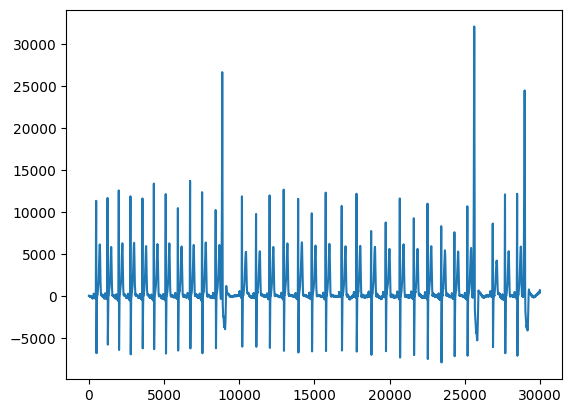

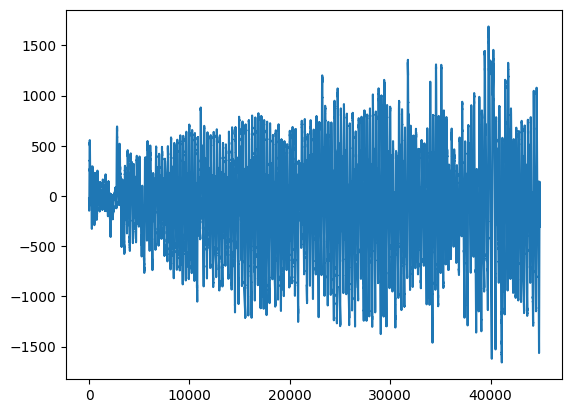

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as sig
import scipy.io as sio
from scipy.io.wavfile import write

# Lectura de señales

##################
## ECG sin ruido
##################

fs_ecg = 1000 # Hz

ecg_one_lead = np.load('ecg_sin_ruido.npy')

plt.figure(1)
plt.plot(ecg_one_lead)

##################
## PPG sin ruido
##################

fs_ppg = 400 # Hz

ppg = np.load('ppg_sin_ruido.npy')

plt.figure(2)
plt.plot(ppg)

####################
# Lectura de audio #
####################

fs_audio_cuca, wav_data_cuca = sio.wavfile.read('la cucaracha.wav')
fs_audio_prueba, wav_data_prueba = sio.wavfile.read('prueba psd.wav')
fs_audio_sil, wav_data_sil = sio.wavfile.read('silbido.wav')

## Visualización temporal de las señales

Antes de realizar el análisis espectral se visualizan las señales en el dominio temporal para observar sus características generales.

Se dispone de un registro ECG, una señal PPG y distintas señales de audio registradas previamente.

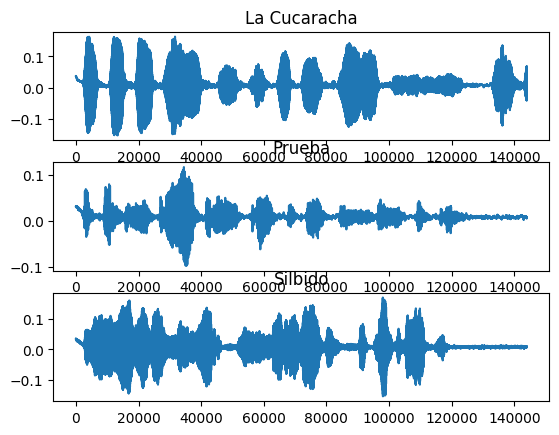

In [2]:
plt.figure(3)

plt.subplot(3,1,1)
plt.title('La Cucaracha')
plt.plot(wav_data_cuca)

plt.subplot(3,1,2)
plt.title('Prueba')
plt.plot(wav_data_prueba)

plt.subplot(3,1,3)
plt.title('Silbido')
plt.plot(wav_data_sil)

# Estimación espectral mediante Welch

La densidad espectral de potencia (PSD) describe cómo se distribuye la potencia de una señal en función de la frecuencia.

Para su estimación se empleó el método de Welch, el cual divide la señal en varios segmentos parcialmente superpuestos, calcula el periodograma de cada uno de ellos y finalmente promedia los resultados.

Esta metodología reduce la varianza de la estimación respecto al periodograma clásico, obteniendo una representación espectral más estable.

En todos los casos se utilizó una ventana Hamming para disminuir el efecto del desparramo espectral.

## PSD del ECG

Se estimó la PSD del registro electrocardiográfico utilizando el método de Welch.

Dado que la mayor parte de la información fisiológicamente relevante del ECG se encuentra en bajas frecuencias, se restringió la visualización a los primeros 40 Hz.

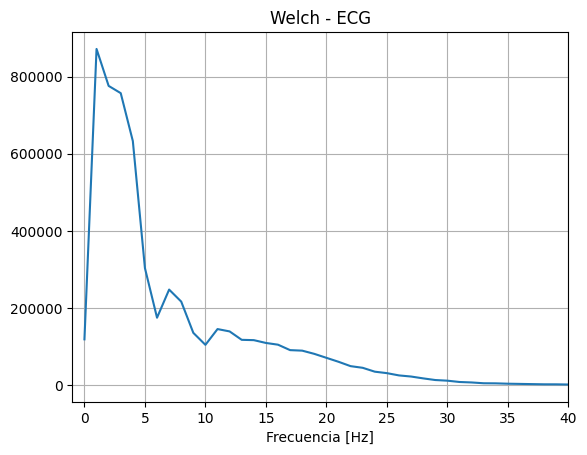

In [3]:
# ECG

tamaño = ecg_one_lead.shape[0]
promedios = 30
nperseg = tamaño // promedios

welch_ecg_fr, welch_ecg = sig.welch(
    ecg_one_lead,
    fs = fs_ecg,
    window = 'hamming',
    nperseg = nperseg,
    noverlap = 15
)

plt.figure(4)
plt.title('Welch - ECG')
plt.xlabel('Frecuencia [Hz]')
plt.xlim(-1,40)
plt.plot(welch_ecg_fr, welch_ecg)
plt.grid()
plt.show()

La PSD obtenida muestra que la mayor parte de la energía del ECG se concentra en bajas frecuencias.

Este comportamiento es consistente con la naturaleza de la señal, cuyos principales componentes fisiológicos presentan variaciones relativamente lentas en el tiempo.

## PSD de la señal PPG

Se realizó el mismo procedimiento para la señal de pletismografía.

Debido a que esta señal está asociada a las variaciones del flujo sanguíneo y al ritmo cardíaco, también se espera una concentración de energía en bajas frecuencias.

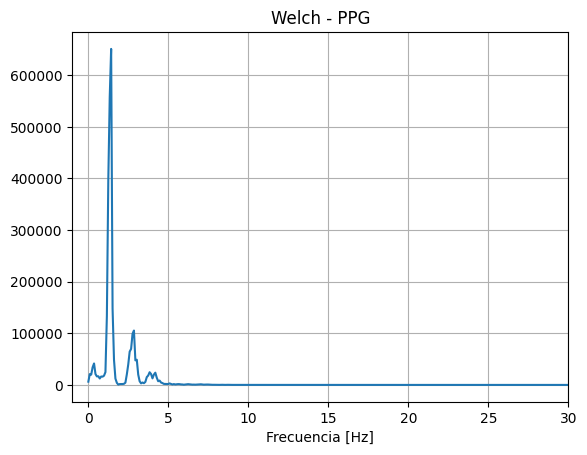

In [4]:
# PPG

tamaño = ppg.shape[0]
promedios = 10
nperseg = tamaño // promedios

welch_ppg_fr, welch_ppg = sig.welch(
    ppg,
    fs = fs_ppg,
    window = 'hamming',
    nperseg = nperseg,
    noverlap = 5
)

plt.figure(5)
plt.title('Welch - PPG')
plt.xlabel('Frecuencia [Hz]')
plt.xlim(-1,30)
plt.plot(welch_ppg_fr, welch_ppg)
plt.grid()
plt.show()

La PSD del PPG presenta una fuerte concentración de energía en bajas frecuencias, asociada principalmente a la frecuencia cardíaca y sus armónicos.

## PSD de la señal de audio

Finalmente se estimó la PSD de una de las señales de audio disponibles.

A diferencia de las señales biomédicas, la señal de audio presenta componentes espectrales distribuidas en una banda de frecuencias considerablemente más amplia.

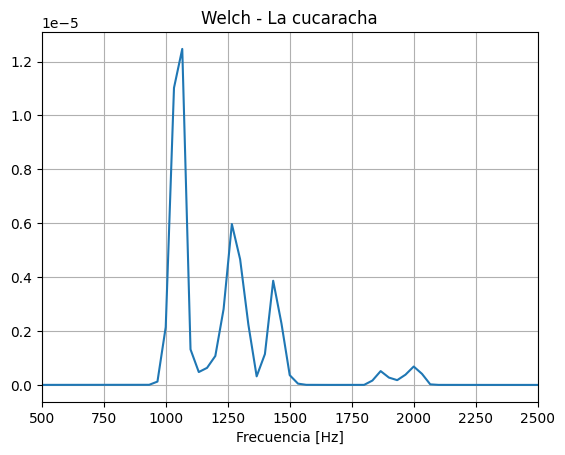

In [5]:
# Audio - La cucaracha

tamaño = wav_data_cuca.shape[0]
promedios = 100
nperseg = tamaño // promedios

welch_cuca_fr, welch_cuca = sig.welch(
    wav_data_cuca,
    fs = fs_audio_cuca,
    window = 'hamming',
    nperseg = nperseg,
    noverlap = 50
)

plt.figure(6)
plt.title('Welch - La cucaracha')
plt.xlabel('Frecuencia [Hz]')
plt.xlim(500,2500)
plt.plot(welch_cuca_fr, welch_cuca)
plt.grid()
plt.show()

La PSD del audio presenta energía distribuida en una región de frecuencias mucho más extensa que las señales biomédicas analizadas previamente.

Esto es esperable debido a la presencia de múltiples componentes armónicas propias de señales musicales y de voz.

# Estimación del ancho de banda

Una vez obtenidas las PSD de cada señal, se calculó la energía acumulada normalizada.

Se definieron como límites del ancho de banda las frecuencias correspondientes al 0.5 % y al 99.5 % de la energía total acumulada.

De esta manera se obtiene una estimación práctica del intervalo de frecuencias que contiene aproximadamente el 99 % de la energía de cada señal.

\[
BW = f_{sup} - f_{inf}
\]

donde:

- \(f_{inf}\) corresponde al 0.5 % de la energía acumulada.
- \(f_{sup}\) corresponde al 99.5 % de la energía acumulada.

In [6]:
# ECG

df_ecg = welch_ecg_fr[1] - welch_ecg_fr[0]
acum = np.cumsum(welch_ecg) * df_ecg
acum_norm = acum / acum[-1]

idx_inf_ecg = np.where(acum_norm >= 0.005)[0][0]
idx_sup_ecg = np.where(acum_norm >= 0.995)[0][0]

f_inf_ecg = welch_ecg_fr[idx_inf_ecg]
f_sup_ecg = welch_ecg_fr[idx_sup_ecg]
BW_ecg = f_sup_ecg - f_inf_ecg


# PPG

df_ppg = welch_ppg_fr[1] - welch_ppg_fr[0]
acum = np.cumsum(welch_ppg) * df_ppg
acum_norm = acum / acum[-1]

idx_inf_ppg = np.where(acum_norm >= 0.005)[0][0]
idx_sup_ppg = np.where(acum_norm >= 0.995)[0][0]

f_inf_ppg = welch_ppg_fr[idx_inf_ppg]
f_sup_ppg = welch_ppg_fr[idx_sup_ppg]
BW_ppg = f_sup_ppg - f_inf_ppg


# Audio

df_cuca = welch_cuca_fr[1] - welch_cuca_fr[0]
acum = np.cumsum(welch_cuca) * df_cuca
acum_norm = acum / acum[-1]

idx_inf_cuca = np.where(acum_norm >= 0.005)[0][0]
idx_sup_cuca = np.where(acum_norm >= 0.995)[0][0]

f_inf_cuca = welch_cuca_fr[idx_inf_cuca]
f_sup_cuca = welch_cuca_fr[idx_sup_cuca]
BW_cuca = f_sup_cuca - f_inf_cuca

## Tabla comparativa de anchos de banda

La siguiente tabla resume los límites inferior y superior de frecuencia obtenidos para cada señal junto con el ancho de banda estimado.

In [7]:
nombres = ['ECG', 'PPG', 'Audio - La cucaracha']

f_inf = [f_inf_ecg, f_inf_ppg, f_inf_cuca]
f_sup = [f_sup_ecg, f_sup_ppg, f_sup_cuca]
BW = [BW_ecg, BW_ppg, BW_cuca]

print('\nTabla de anchos de banda estimados')
print('-------------------------------------------------------------')
print('{:<25s} {:>12s} {:>12s} {:>12s}'.format('Señal', 'f_inf [Hz]', 'f_sup [Hz]', 'BW [Hz]'))
print('-------------------------------------------------------------')

for i in range(len(nombres)):
    print('{:<25s} {:>12.2f} {:>12.2f} {:>12.2f}'.format(
        nombres[i],
        f_inf[i],
        f_sup[i],
        BW[i]
    ))

print('-------------------------------------------------------------')


Tabla de anchos de banda estimados
-------------------------------------------------------------
Señal                       f_inf [Hz]   f_sup [Hz]      BW [Hz]
-------------------------------------------------------------
ECG                               0.00        36.00        36.00
PPG                               0.09         6.77         6.68
Audio - La cucaracha           1000.00      2033.33      1033.33
-------------------------------------------------------------


# Conclusiones

Se estimó la densidad espectral de potencia de señales ECG, PPG y audio mediante el método de Welch.

Los resultados muestran que las señales biomédicas concentran la mayor parte de su energía en bajas frecuencias, mientras que la señal de audio presenta un contenido espectral considerablemente más amplio.

A partir de la energía acumulada de cada PSD se obtuvo una estimación del ancho de banda efectivo de cada señal, permitiendo comparar cuantitativamente sus contenidos espectrales.

Los resultados obtenidos son consistentes con la naturaleza física de cada señal y constituyen una herramienta útil para el posterior diseño de filtros digitales y sistemas de procesamiento de señales.